# Advantage Actor-Critic Method(A2C) or TD actor-critic method

- **Advantage function $A(s, a)$**:
    - quantifies how much advantageous a specific action is compared to the average action available in state
    - it reduces variance, enables faster convergence, and stabilizes training by replacing absolute returns with a baseline-subtracted value.
    - $A(s, a) = Q(s, a) - V(s)$  -> it  needs two different Neural network to represent Q and V
    - $A(s, a) = (r_{t+1} + \gamma * V(s_{t+1}) - V(s_t)$ -> single neural network to represent V 
             

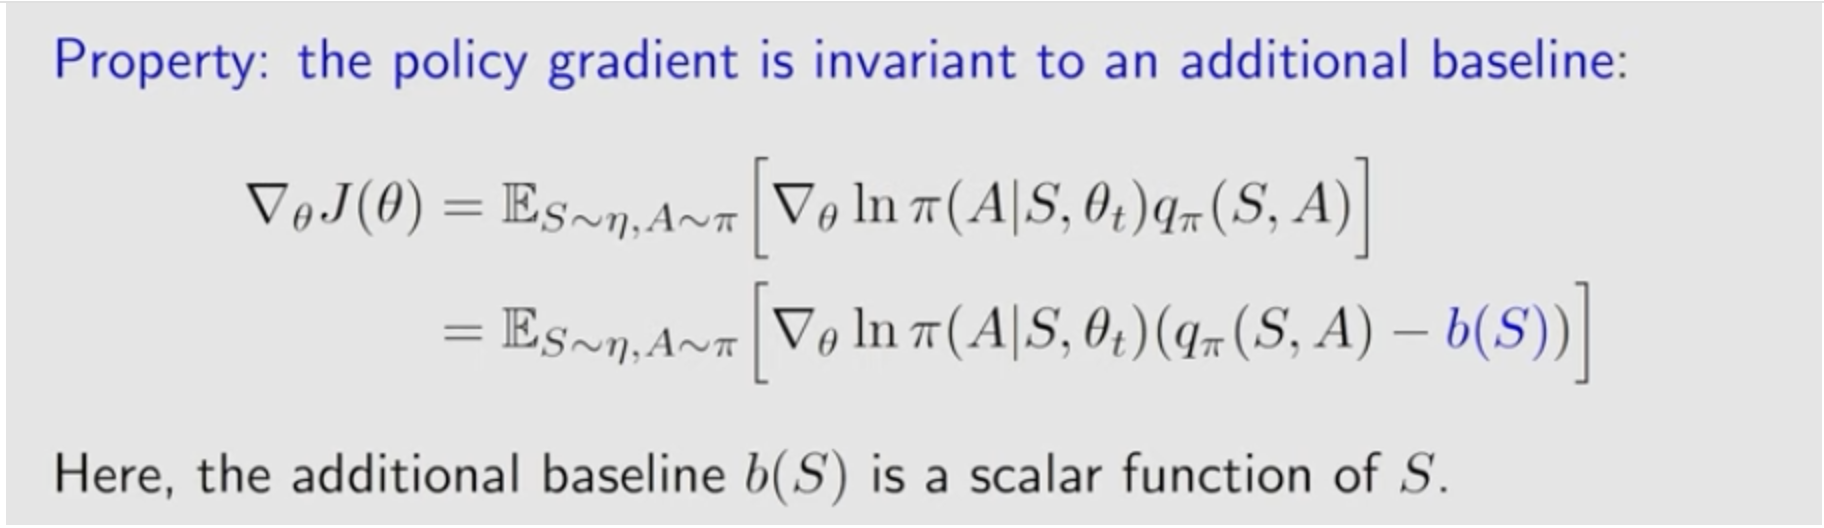

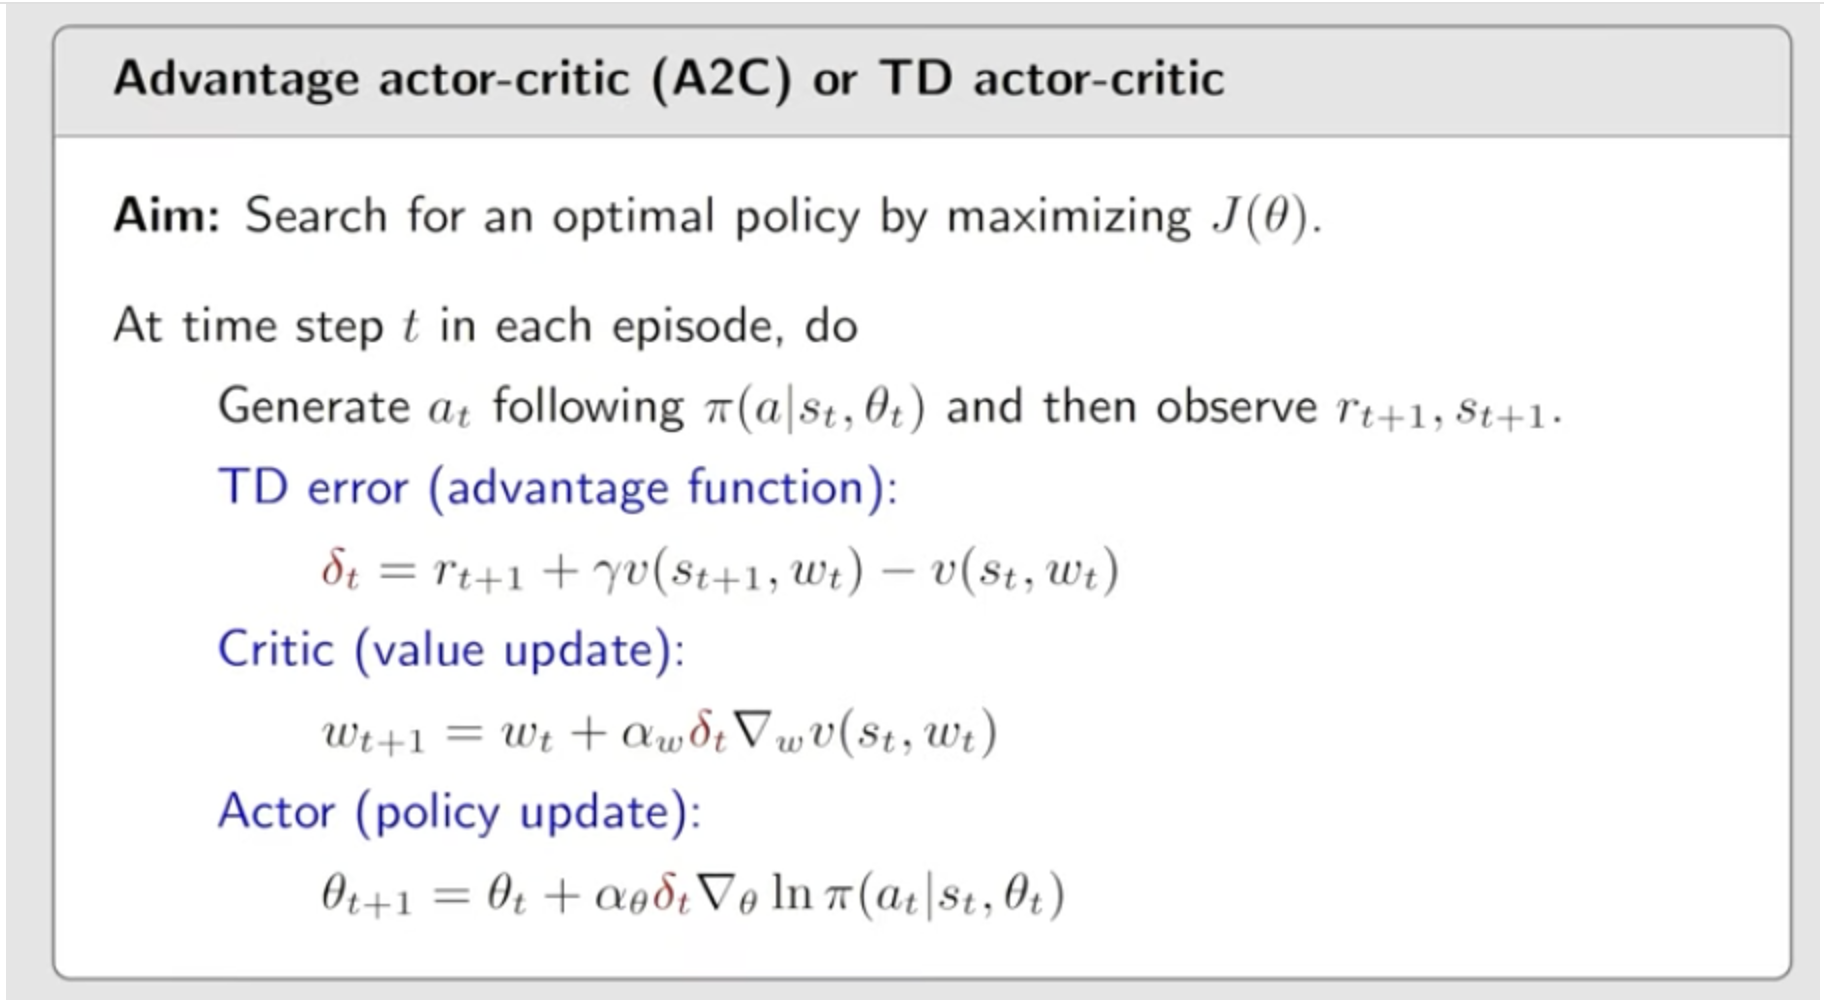

In [1]:
import random
import math
import torch
from torch import nn 
from torch import optim
from collections import deque
from torch.distributions import Categorical

from frozen_lake_environment import (generate_grid_randomly,
                                     FrozenLakeEnvironment,
                                     State)
import numpy as np
from matplotlib import pyplot
from visual_utils import (render_policy_and_value, 
                          animate_policy_value_video,
                          plot_trajectory_history)
import torch.nn.functional as F
from tqdm import tqdm

In [2]:
lake_grid = [["G", "H", "F", "F"],
             ["F", "F", "F", "F"],
             ["F", "F", "H", "F"],
             ["F", "H", "S", "F"]]

reward_points = {
    "S": 0,
    "G": 10,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [3]:
class Actor(nn.Module):
    """
    Policy network π(a | s; θ).
    Outputs a categorical distribution over discrete actions.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, act_dim)
        )

    def forward(self, x: torch.Tensor) -> Categorical:
        logits = self.net(x)
        return Categorical(logits=logits)

    def log_prob(self, x: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        return self.forward(x).log_prob(a)
            
    def policy_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        policy = np.zeros(env.n_states, dtype=np.int8)
        for state in states:
            state_vec = state.get_state_feature_vec(env.n_states)
            state_vec = torch.Tensor(state_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                action_probs = self.forward(state_vec).probs
                policy[state.idx] = torch.argmax(action_probs, dim=-1).item()
        return policy

In [4]:
class Critic(nn.Module):
    """
    state-value network V(s; φ).
    Outputs one scalar per discrete action → index by chosen action.
    """
    def __init__(self, state_dim: int, act_dim: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),  nn.ReLU(),
            nn.Linear(hidden, 1)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Returns Q-values for all actions, shape (batch, act_dim)."""
        return self.net(x)
    def v_table(self, env):
        states = [State(s_idx, env.n_cols) for s_idx in range(env.n_states)]
        V = np.zeros(env.n_states, dtype=np.float32)
        for state in states:
            state_feat_vec = state.get_state_feature_vec(env.n_states)
            state_feat_vec = torch.Tensor(state_feat_vec).unsqueeze(0) # 1 X feat_vec
            with torch.no_grad():
                v_value = self.forward(state_feat_vec).squeeze(1)
            V[state.idx] = v_value.item()
        return V

In [5]:
critic = Critic(frozen_lake.n_states, frozen_lake.n_actions)
critic

Critic(
  (net): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=1, bias=True)
  )
)

In [6]:
state_vec = frozen_lake.find('S').get_state_feature_vec(frozen_lake.n_states)
state_vec = torch.Tensor(state_vec).unsqueeze(0)
state_vec.shape

torch.Size([1, 16])

In [7]:
critic(state_vec)

tensor([[-0.0359]], grad_fn=<AddmmBackward0>)

In [8]:
critic.v_table(frozen_lake)

array([ 0.01817083, -0.03555985, -0.00040423, -0.00813102, -0.01094731,
       -0.0205545 ,  0.00475197, -0.00414769, -0.02304161, -0.01408384,
       -0.03838937, -0.03063919, -0.01404938, -0.00831299, -0.03594851,
       -0.03634892], dtype=float32)

In [9]:
class A2CAgent:
    def __init__(self, env, actor, critic, lr_actor, lr_critic, gamma):
        self.env = env
        self.actor = actor
        self.critic = critic                                       
        self.opt_actor  = optim.Adam(self.actor.parameters(),  lr=lr_actor)
        self.opt_critic = optim.Adam(self.critic.parameters(), lr=lr_critic)
        self.gamma = gamma

    def critic_update(self, s, r, next_s, mask):
        with torch.no_grad():
            v_next = self.critic(next_s).squeeze(-1)                 
            target = r + self.gamma * v_next * mask   

        v = self.critic(s).squeeze(-1)
        critic_loss = F.mse_loss(v, target)

        self.opt_critic.zero_grad()
        critic_loss.backward()
        nn.utils.clip_grad_norm_(self.critic.parameters(), 1.0)
        self.opt_critic.step()

        # return advantage as a detached scalar for the actor
        with torch.no_grad():
            # advantage = (r + gamma * v_next) - v 
            advantage = (target - self.critic(s).squeeze(-1))
        return critic_loss.item(), advantage

    def actor_update(self, s, a, advantage):
        log_prob = self.actor.log_prob(s, a)     
        actor_loss = -(log_prob * advantage).mean()

        self.opt_actor.zero_grad()
        actor_loss.backward()
        nn.utils.clip_grad_norm_(self.actor.parameters(), 1.0)
        self.opt_actor.step()
        return actor_loss.item()

    def update(self, s, a, r, next_s, done):
        s      = torch.FloatTensor(s).unsqueeze(0)
        a      = torch.LongTensor([a])
        r      = torch.FloatTensor([r])
        next_s = torch.FloatTensor(next_s).unsqueeze(0)
        mask   = torch.FloatTensor([0.0 if done else 1.0])

        critic_loss, advantage = self.critic_update(s, r, next_s, mask)
        actor_loss = self.actor_update(s, a, advantage)
        return critic_loss, actor_loss

    @torch.no_grad()
    def sample_action(self, s, greedy=False):
        s = torch.FloatTensor(s).unsqueeze(0)
        dist = self.actor(s)
        if greedy:
            return dist.probs.argmax(dim=-1).item()
        return dist.sample().item()

In [10]:
def train(env, n_episodes, gamma=0.99, lr_actor=1e-4, lr_critic=1e-4):
    actor = Actor(env.n_states, env.n_actions)
    critic = Critic(env.n_states, env.n_actions)
    agent = A2CAgent(env, actor, critic, lr_actor, lr_critic, gamma)
    trajectory_histories = []
    policy_histories = []
    V_histories = []
    for episode_idx in range(n_episodes):
        s = env.find('S')
        s_feat = s.get_state_feature_vec(env.n_states)
        a = agent.sample_action(s_feat)
        trajectory = []
        G  = 0
        while True:
            trajectory.append(s.coord)
            result = env.step(s, a)
            r = result["reward"]            
            next_s = result["new_state"]
            next_s_feat = next_s.get_state_feature_vec(env.n_states)
            is_terminated = result["is_terminated"]
            # print("s: ", s.coord, "a: ", a, "r:", r, "n_s: ", next_s.coord, "done: ", is_terminated)
    
            c_loss, a_loss = agent.update(s_feat, a, r, next_s_feat, is_terminated)
            
            s = next_s
            s_feat = next_s_feat
            a = agent.sample_action(s_feat)

            G += r
            if is_terminated:
                break

        trajectory_histories.append(trajectory)
        
        if episode_idx % 500 == 0:
            print("critic loss: ", c_loss, " actor loss: ", a_loss)
            print("Return: ", G)
            
            policy = agent.actor.policy_table(env)
            v_table = agent.critic.v_table(env)
            policy_histories.append(policy)
            V_histories.append(v_table)
            # print("Q table", Q_table)
            # print("policy: ", policy)

    return policy_histories, V_histories, trajectory_histories

In [11]:
# lake_grid = [["G", "H", "F", "F"],
#              ["F", "F", "F", "F"],
#              ["F", "F", "H", "F"],
#              ["F", "H", "S", "F"]]

lake_grid = [["F", "F", "S", "F", "H"],
             ["F", "F", "H", "F", "F"],
             ["F", "F", "F", "G", "F"],
             ["F", "H", "F", "F", "F"],
             ["H", "H", "F", "F", "F"]]

reward_points = {
    "S": 0,
    "G": 1,
    "F": 0,
    "H": 0
}

frozen_lake = FrozenLakeEnvironment(grid=lake_grid,
                                    reward_points=reward_points,
                                    slippery=True)

In [12]:
policy_histories, v_histories, trajectory_histories = train(frozen_lake, n_episodes=10000)

critic loss:  0.0012334731873124838  actor loss:  0.04812607169151306
Return:  0.0
critic loss:  0.15719465911388397  actor loss:  0.03646964207291603
Return:  1.0
critic loss:  0.0085678705945611  actor loss:  0.012539498507976532
Return:  1.0
critic loss:  0.0019276560051366687  actor loss:  0.0028346881736069918
Return:  1.0
critic loss:  0.00045755592873319983  actor loss:  0.0007362777250818908
Return:  1.0
critic loss:  0.004564815200865269  actor loss:  0.00197019474580884
Return:  1.0
critic loss:  0.002612064592540264  actor loss:  0.002233442384749651
Return:  1.0
critic loss:  0.005452146288007498  actor loss:  0.003883626079186797
Return:  1.0
critic loss:  0.7395657896995544  actor loss:  -1.5868459939956665
Return:  0.0
critic loss:  0.0007708773482590914  actor loss:  0.0006803795113228261
Return:  1.0
critic loss:  0.0024713838938623667  actor loss:  0.0019915620796382427
Return:  1.0
critic loss:  0.8919879794120789  actor loss:  -2.035183906555176
Return:  0.0
critic 

In [13]:
policy = policy_histories[-1]
v_table = v_histories[-1]

In [14]:
policy

array([2, 2, 2, 1, 3, 3, 1, 3, 1, 1, 2, 2, 2, 3, 0, 3, 3, 3, 3, 3, 3, 3,
       3, 3, 3], dtype=int8)

In [15]:
v_table

array([0.81101906, 0.8178748 , 0.8552261 , 0.913334  , 0.8878104 ,
       0.75306803, 0.7384756 , 0.78378564, 0.9725867 , 0.9075788 ,
       0.732194  , 0.8204161 , 0.8886941 , 0.7655278 , 0.972513  ,
       0.4410155 , 0.8376592 , 0.8127525 , 0.85778683, 0.91855556,
       0.753781  , 0.82316476, 0.7251843 , 0.7817726 , 0.82495207],
      dtype=float32)

In [16]:
# Render Policy

In [17]:
import pandas as pd
from IPython.display import display

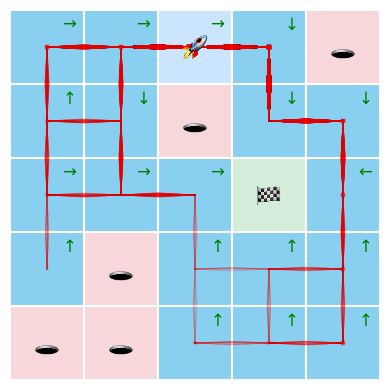

In [18]:
plot_trajectory_history(frozen_lake, trajectory_histories, policy)